In [29]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from netCDF4 import Dataset
from mpl_toolkits.basemap import Basemap
from matplotlib import colors

# -- Load Sen's slope data --
file_id = Dataset('/home/jamesash/projects/climate/data/chl/senslope_nomask_20260328.nc')
slope = np.array(file_id.variables["slope"][:], dtype='float64')
lat   = file_id.variables["latitude"][:].copy()
lon   = file_id.variables["longitude"][:].copy()
file_id.close()

# Convert slope to per year
slope_yr = slope * 365.25
slope_yr = slope_yr.clip(min = -0.0035, max = 0.0035)

# -- Set up diverging norm centered on zero --
divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(slope_yr), vcenter=0, vmax=np.nanmax(slope_yr))

# -- Set up grids --
lon_grid, lat_grid = np.meshgrid(lon, lat)

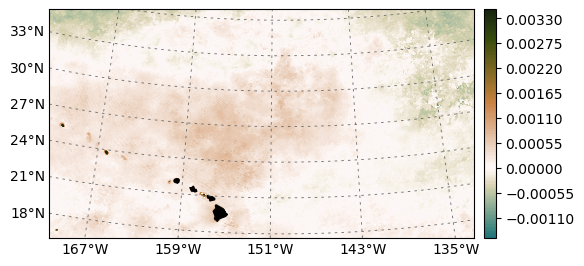

In [36]:

# -- Plot --
fig, ax = plt.subplots(1, 1, figsize=(6.6, 5.5))

m = Basemap(projection='lcc', resolution='l',
            llcrnrlat=16, urcrnrlat=35.5,
            llcrnrlon=-170, urcrnrlon=-130,
            lat_0=30, lon_0=-150,
            width=5.1E6, height=5E6,
            ax=ax)

x, y = m(lon_grid, lat_grid)

contour = m.contourf(x, y, slope_yr, cmap=cmocean.cm.tarn_r,
                     levels=100, extend='neither', norm=divnorm)

m.fillcontinents(color='black')
m.drawcoastlines(color='black')

parallels = m.drawparallels(np.arange(18, 40, 3), labels=[1,0,0,0], textcolor = 'black', color = "dimgrey", fontsize=10, dashes=(3, 5), linewidth = 0.6)
meridians =  m.drawmeridians(np.arange(-175, -130, 8), labels=[0,0,0,1], textcolor = 'black', color = "dimgrey", fontsize=10, dashes=(3, 5),linewidth = 0.6)

# cbar = fig.colorbar(contour, shrink=0.965, pad=0.02)
cbar = fig.colorbar(contour, shrink=0.54, pad=0.02)
# cbar.set_label('mg m$^{-3}$ year$^{-1}$', fontsize=11)

# plt.title("Sen's slope of summertime chlorophyll anomaly from 1998 to 2025 [mg m$^{-3}$ year$^{-1}$]", fontsize=13)

# plt.savefig('senslope_summer_map.png', bbox_inches='tight', dpi=300)
plt.show()